### WATCH-IT MOVIE LICENSING PREDICTION
#### Authored by: Michael Otu - Data Scientist

Objectives of this project

This project seeks to use data-driven solutions to help managers identify what titles to license to generate more revenue for the business. To achieve this, we will be applying core data analysis, data science principles, and machine learning techniques to explore and utilize our data, effectively turning raw data into actionable insights for our stakeholders. Our overall project will:

    - Analyze the training dataset to determine how different features are related to revenue
    - Build a Machine Learning model to predict revenue category
    - Predict the value of revenue_category variables using the test set to help managers identify titles suitable for licensing

The file is partitioned into 9 distinct sections, some of which have subsections. They include:

    - SECTION ONE: IMPORT LIBRARIES AND LOAD DATASET
    - SECTION TWO: EXPLORATORY DATA ANALYSIS
    - SECTION THREE: FEATURE ENGINEERING AND PREPROCESSING PIPELINE
    - SECTION FOUR: TRAIN-TEST SPLIT
    - SECTION FIVE: BUILDING PREPROCESSING PIPELINES
    - SECTION SIX: BASELINE MODEL SELECTION, TRAINING, AND EVALUATION
    - SECTION SEVEN: USING ADVANCED MODELS AND CROSS-VALIDATION
    - SECTION EIGHT: FEATURE IMPORTANCE AND INSIGHTS
    - SECTION NINE: FINAL MODEL TRAINING, TESTING, AND PREDICTION

Visualization, commenting, and Markdown have been incorporated to enhance readability. 



### SECTION ONE: IMPORT LIBRARIES AND LOAD DATASET

In [279]:
# Import all necessary libraries for cleaner code
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, cross_val_score
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_SEED = 42

In [281]:
# define a function that loads the training data using its file path into a DataFrame

def load_train_data(file_path = "C:/Users/blaqj/OneDrive/Documents/Projects/Interswitch assessment/watchit_revenue_assessment/train.csv"):
    train_df = pd.read_csv(file_path)
    return train_df

train_df = load_train_data()
train_df.head() # calls the first few rows of a DataFrame

,title,country,genres,language,writer_count,title_adaption,censor_rating,release_date,runtime,dvd_release_date,...,likes,overall_views,dislikes,ratings_imdb,ratings_tomatoes,ratings_metacritic,special_award,awards_win,awards_nomination,revenue_category
0,Pooh's Heffalump Movie,USA,"Animation, Comedy, Family, Fantasy, Musical, M...",English,3.0,True,G,11-Feb-05,68 min,24-May-05,...,NaN,NaN,NaN,6.4/10,80%,64/100,0,0,1,High
1,Yeh Jawaani Hai Deewani,India,"Comedy, Drama, Musical, Romance","Hindi, English, French",2.0,True,Not Rated,31-May-13,160 min,15-Jul-13,...,124.0,127528.0,12.0,7.1/10,67%,0,0,22,92,Low
2,Tae Guk Gi: The Brotherhood of War,South Korea,"Action, Drama, War",Korean,4.0,False,R,24-Sep-04,140 min,15-Feb-05,...,614.0,351123.0,18.0,8.1/10,80%,64/100,0,12,7,Low
3,"Book of Eli, The",USA,"Action, Adventure, Drama, Thriller",English,1.0,False,R,15-Jan-10,118 min,15-Jun-10,...,NaN,NaN,NaN,6.9/10,47%,53/100,0,3,16,High
4,Blind Dating,USA,"Comedy, Romance",English,1.0,False,PG-13,26-Apr-07,95 min,05-Feb-08,...,693.0,970306.0,36.0,6.1/10,25%,0,0,0,0,Low


### SECTION TWO: EXPLORATORY DATA ANALYSIS

==== Train ====
(2400, 22)
object     13
float64     5
int64       3
bool        1
Name: count, dtype: int64
dislikes            444
likes               444
comments            426
overall_views       317
writer_count         94
dvd_release_date     69
censor_rating        38
language              5
release_date          4
title                 2
dtype: int64


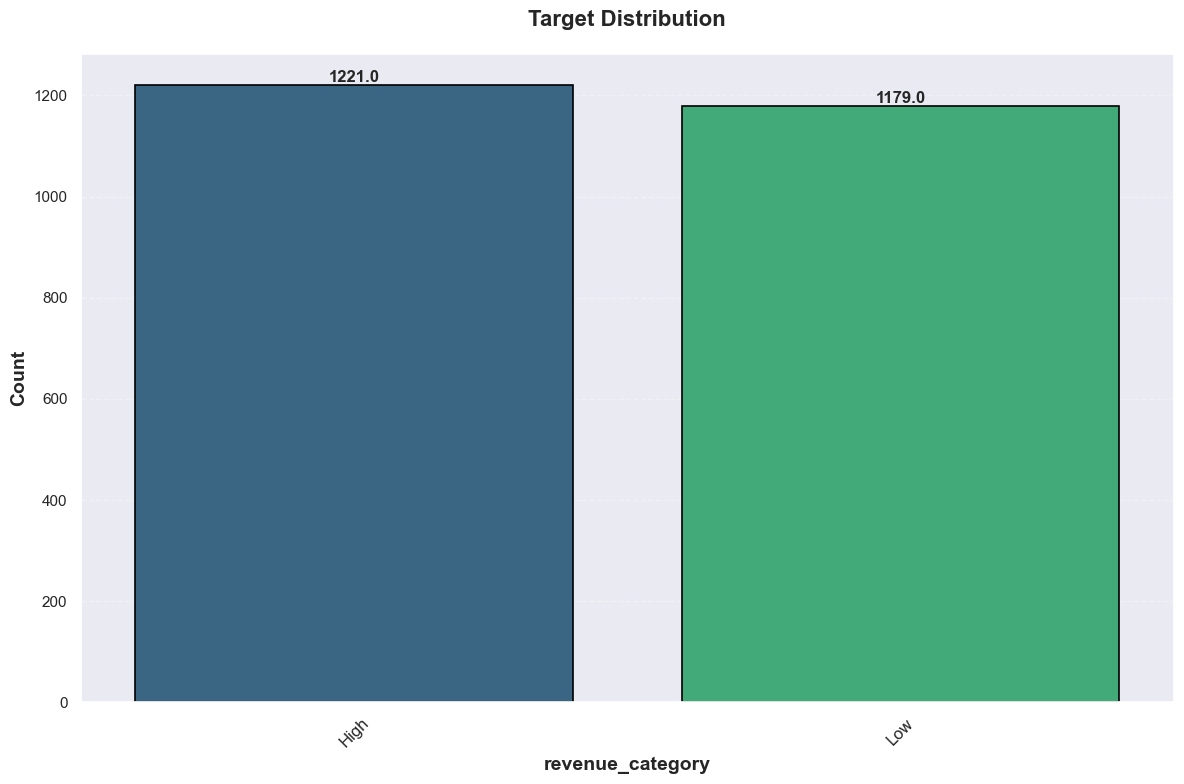

In [284]:
def summarize_df(df, name="Dataset"):
    print(f"==== {name} ====") # prints out the name of the dataset
    print(df.shape) # shows up the shape of the dataset i.e, number of rows and columns
    print(df.dtypes.value_counts()) # shows us the data types in each column
    print(df.isnull().sum().sort_values(ascending=False).head(10)) # this prints out 10 columns with most missing values

def plot_target_distributions(df, target="revenue_category"):
    # Give the figure specific dimensions for optimal readability
    plt.figure(figsize=(12, 8))
    
    # Create a countplot with enhanced visual properties
    ax = sns.countplot(x=target, data=df, hue=target, palette='viridis', saturation=0.8, edgecolor='black', linewidth=1.2)

    # This will annotate each bar with its exact count value
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    # Chart title with enhanced typography
    plt.title("Target Distribution", fontsize=16, fontweight='bold', pad=20)

    # This gives the axis labels clear formatting
    plt.xlabel(target, fontsize=14, fontweight='bold')
    plt.ylabel("Count", fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, fontsize=12) # Rotates the axis to give long category names better readability
    plt.grid(axis='y', alpha=0.3, linestyle='--') # Adds grid lines to estimate value more specifically
    plt.tight_layout() # This adjusts the layout to prevent label clipping
    plt.show() # Displays the plot

# Eun the functions on the training data
summarize_df(train_df, "Train")
plot_target_distributions(train_df)

### SECTION THREE: FEATURE ENGINEERING AND PREPROCESSING PIPELINE

Data Cleaning and feature engineering are the most intricate, time-consuming and imperative parts of the machine learning workflow. They ensure that the raw data is modified in a format the interpreter can easily understand and work with.

For this section, several preprocessing and feature engineering techniques were used. They include:

    - converting dates to datetime (it was also important to specify the format to avoid errors or conflicts that come with mixed date formats)
    - Feature extraction was applied to capture seasonality and trends
    - Imputation for missing values using statistical measures and constants (Imputation was chosen against others because of the low percentage of missing values in each column)
    - Binary indicators were used to point out missingness to explicitly encode the fact that data was missing.
    - Engagement features were applied to measure the quality of reception and overall audience interaction

All these techniques were wrapped in a function for seamless reproducibility. This came in handy when it came time to predict on the test data the test data

In [288]:
# This function cleans and engineers features from the raw data
def clean_and_engineer(df):
    df = df.copy() # it is important to work on a copy to avoid modifying the main DataFrame

    # ----Date Features----
    # Here we convert release and DVD release to datetime objects
    for col in ["release_date", "dvd_release_date"]:
        df[col] = pd.to_datetime(df[col], errors="coerce", format="mixed")

    # Extract both year and month from the release date
    df["release_year"] = df["release_date"].dt.year
    df["release_month"] = df["release_date"].dt.month

     # Calculate delay between cinema release and DVD release (in days)
    df["dvd_delay_days"] = (df["dvd_release_date"] - df["release_date"]).dt.days

    # ----Imputation for missing release information in the dataset----
    # Use mode to fill missing year with or fallback = 2000
    release_year_mode = df["release_year"].mode()[0] if df["release_year"].notna().any() else 2000
    # Use mode to fill missing month or fallback = January
    release_month_mode = df["release_month"].mode()[0] if df["release_month"].notna().any() else 1
    # Use median to fill missing DVD delay or fallback = 0
    dvd_delays_median = df["dvd_delay_days"].median() if df["dvd_delay_days"].notna().any() else 0

    df["release_year"] = df["release_year"].fillna(release_year_mode)
    df["release_month"] = df["release_month"].fillna(release_month_mode)
    df["dvd_delay_days"] = df["dvd_delay_days"].fillna(dvd_delays_median)

    # Missing Flags for binary indicators
    df["is_missing_release_date"] = df["release_date"].isna().astype(int)
    df["is_missing_dvd_delay"] = df["dvd_release_date"].isna().astype(int)

    # --- Engagement features ---
    # Replace NaN values in likes, dislikes, comments, and views with zero
    for col in ["likes", "dislikes", "comments", "overall_views"]:
        df[col] = df[col].fillna(0)
        
    # This calculates the like rate by dividing likes by total (likes + dislikes) + 1 to avoid dividing by 0
    df["like_rate"] = df["likes"] / (df["likes"] + df["dislikes"] + 1)
    
    # This calculates engagement by adding total interaction signals (likes + comments + views)
    df["engagement"] = df["likes"] + df["comments"] + df["overall_views"]

    # --- Awards features ---
    # Fill missing writer counts with zero
    df["writer_count"] = df["writer_count"].fillna(0)
    df["total_awards"] = df[["awards_win", "awards_nomination", "special_award"]].sum(axis=1)

    # --- Categorical features ---
    # Fill missing categorical values with placeholder "Unknown"
    for col in ["censor_rating", "country", "language"]:
        df[col] = df[col].fillna("Unknown")

    # --- Title features ---
    # Fill missing titles with placeholders
    df["title"] = df["title"].fillna("Unknown_Title") 
    df["title_length"] = df["title"].astype(str).apply(len) # Calculates the title length in characters
    df["title_word_count"] = df["title"].astype(str).apply(lambda x: len(x.split())) # TAccounts for the title word count (split on spaces)

    # returns the cleaned and feature-engineered DataFrame
    return df

# Run the function to apply cleaning and feature engineering on training data
train_df = clean_and_engineer(train_df)

In [290]:
# ran the EDA summarize function again to check how well my data was cleaned
summarize_df(train_df, "Train")

==== Train ====
(2400, 32)
object            11
float64           10
int64              6
datetime64[ns]     2
int32              2
bool               1
Name: count, dtype: int64
dvd_release_date           69
release_date                4
title                       0
awards_win                  0
awards_nomination           0
revenue_category            0
release_year                0
release_month               0
dvd_delay_days              0
is_missing_release_date     0
dtype: int64


### SECTION FOUR: TRAIN-TEST SPLIT

In [293]:
# Separate features (X) and target (y)
x = train_df.drop(columns=["revenue_category", 'title']) # Drops target + title (not predictive)
y = train_df["revenue_category"].map({"Low": 0, "High": 1}) # Encode target into binary (0 = Low, 1 = High)
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.2, stratify=y, random_state=42) # Split data into train + validation

In [295]:
# Seperate features by type for preprocessing

# This explicitly lists categorical features to be one-hot encoded
categorical_features = ["country", "language", "censor_rating"]
# Automatically detects all numerical features, whether int or float
numerical_features = x_train.select_dtypes(include=[np.number]).columns.tolist()

### SECTION FIVE: BUILDING PREPROCESSING PIPELINES

In [298]:
# For numeric preprocessing, scale values so models aren't biased by feature magnitude
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler()) # standardize numerical features
])

# For categorical preprocessing, encode categories into numerical one-hot vectors
categorical_transformer = Pipeline(steps=[
    ("encoded", OneHotEncoder(handle_unknown="ignore")) # OneHotEncoder turns categories into binary features
])

# Finally, combine both pipelines into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [300]:
# Combine preprocessing and model into one pipeline
clf = Pipeline(steps=[
               ("preprocessor", preprocessor),
               ("model", LogisticRegression(max_iter=1000, random_state=42))
])

# Fit pipeline on training data
clf.fit(x_train, y_train)
# Get predictions on validation set
preds = clf.predict(x_val)

### SECTION SIX: BASELINE MODEL SELECTION, TRAINING AND EVALUATION

In this section, we utilize baseline models to set a performance benchmark. 

    - Logistic Regression is used as a linear baseline that works well on standardized numerical features.
    - Decision Tree is included as a simple non-linear model that can capture feature interactions.

Both models are wrapped inside a pipeline with preprocessing (scaling + encoding) to ensure consistency. We evaluate the models on the validation set using:

    - Classification Report (precision, recall, F1-score, and support).
    - Confusion Matrix (visual comparison of prediction errors).

This step helps us understand:

    - How simple models perform on the problem.
    - Which class (High vs. Low revenue) is harder to predict.
    - Whether more advanced models are needed.

In [304]:
models ={
    # This is a dictionary of models to be compared
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Trees": DecisionTreeClassifier(max_depth=5, random_state=42)
}

# Loop through the models
for name, model in models.items():
    # Build pipeline with preprocessing and current model
    clf = Pipeline(steps=[
               ("preprocessor", preprocessor),
               ("model", LogisticRegression(max_iter=1000, random_state=42))
    ])

    clf.fit(x_train, y_train) # fit pipeline on training data
    preds = clf.predict(x_val) # Get predictions on validation set
    # Print model name and classification metrics for evaluation
    print(f"\n{name}")
    print(classification_report(y_val, preds))


Logistic Regression
              precision    recall  f1-score   support

           0       0.78      0.76      0.77       236
           1       0.78      0.80      0.79       244

    accuracy                           0.78       480
   macro avg       0.78      0.78      0.78       480
weighted avg       0.78      0.78      0.78       480


Decision Trees
              precision    recall  f1-score   support

           0       0.78      0.76      0.77       236
           1       0.78      0.80      0.79       244

    accuracy                           0.78       480
   macro avg       0.78      0.78      0.78       480
weighted avg       0.78      0.78      0.78       480



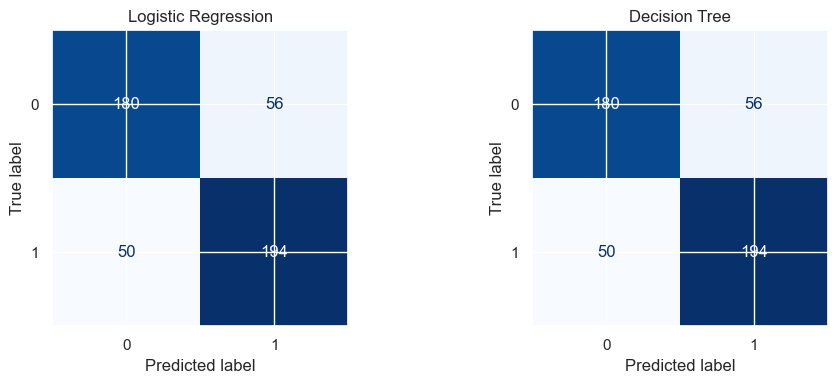

In [306]:
# Plot Confusion matrix for both models

fig, axes = plt.subplots(1, 2, figsize=(10,4))

# ----Logistic Regression----
cm = confusion_matrix(y_val, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=clf.classes_)
disp.plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Logistic Regression")

#----Decision Tree----
cm = confusion_matrix(y_val, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=clf.classes_)
disp.plot(ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Decision Tree")

# Adjust the layout to avoid overlap
plt.tight_layout()
plt.show()

### SECTION SEVEN: USING ADVANCED MODELS AND CROSS VALIDATION

After evaluating the baselines, we move to more powerful ensemble models:

    - Random Forest fot its bagging of multiple decision trees for robustness.
    - LightGBM which is a gradient boosting framework optimized for speed and performance.

To ensure reliable evaluation, we use Stratified K-Fold Cross-Validation (CV) with multiple scoring metrics:

    - Accuracy for overall correctness.
    - Precision for proportion of predicted High revenue movies that are correct.
    -Recall for its ability to detect all true High revenue movies.
    -F1-score for its harmonic mean of precision and recall, balancing both metrics.

We report the mean ± standard deviation across folds to assess both performance and stability. This section allows us to:

    -Compare ensemble models against baselines.
    -Identify the best-performing model.
    -Verify robustness across folds (not just one train/validation split).

In [310]:
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

advanced_models = {
    # dictionary of advanced models
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

# loop through advanced models
for name, model in advanced_models.items():
    # build pipeline with preprocessing and current model
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    # Fit the models
    clf.fit(x_train, y_train)
    # Get predictions on validation set
    preds = clf.predict(x_val)
    # Print model name and classification metrics for evaluation
    print(f"\n{name}")
    print(classification_report(y_val, preds))


Random Forest
              precision    recall  f1-score   support

           0       0.83      0.80      0.81       236
           1       0.81      0.84      0.82       244

    accuracy                           0.82       480
   macro avg       0.82      0.82      0.82       480
weighted avg       0.82      0.82      0.82       480

[LightGBM] [Info] Number of positive: 977, number of negative: 943
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000748 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2164
[LightGBM] [Info] Number of data points in the train set: 1920, number of used features: 41
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508854 -> initscore=0.035420
[LightGBM] [Info] Start training from score 0.035420

LightGBM
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       236
           1       0.83      0.85      0.84       24

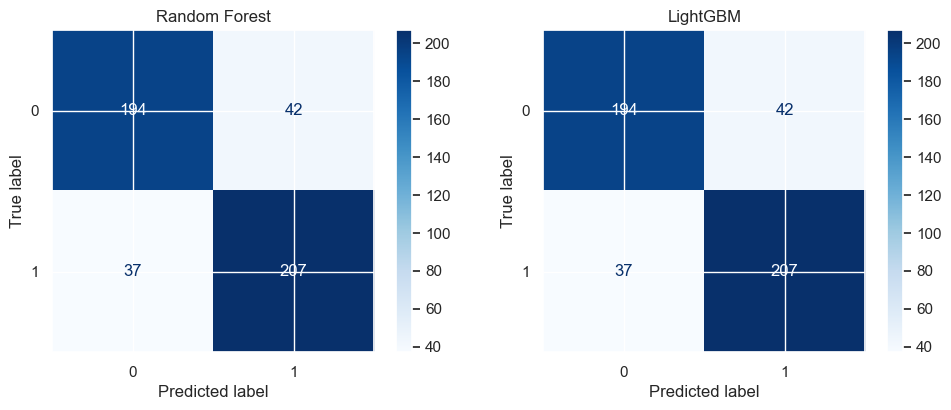

In [312]:
# Plot confusion matrix for both advanced models

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

#----Random Forest----
cm1 = confusion_matrix(y_val, preds)
disp1 = ConfusionMatrixDisplay(cm1, display_labels=clf.classes_)
disp1.plot(cmap="Blues", ax=ax1)
ax1.set_title("Random Forest")

#----LightGBM---- 
cm2 = confusion_matrix(y_val, preds)
disp2 = ConfusionMatrixDisplay(cm2, display_labels=clf.classes_)
disp2.plot(cmap="Blues", ax=ax2)
ax2.set_title("LightGBM")

# Adjust the layout to avoid overlap
plt.tight_layout()
plt.show()

#### RUN CROSS VALIDATION FOR ROBUSTNESS

In [315]:
# This defines the CV strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Select the models to evaluate
models = {
    # Dictionary of models
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

# loop through models
for name, model in models.items():
    # Build pipeline with preprocessing and current model
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Evaluate using cross-validation (F1 score)
    scores = cross_val_score(clf, x, y, cv=cv, scoring="f1")

    # Report mean and variability
    print(f"{name} CV F1: {np.mean(scores): 4f} ± {np.std(scores): 4f}")

Random Forest CV F1:  0.835911 ±  0.008831
[LightGBM] [Info] Number of positive: 976, number of negative: 944
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000774 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2170
[LightGBM] [Info] Number of data points in the train set: 1920, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508333 -> initscore=0.033336
[LightGBM] [Info] Start training from score 0.033336
[LightGBM] [Info] Number of positive: 977, number of negative: 943
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000778 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2163
[LightGBM] [Info] Number of data points in the train set: 1920, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.5

### SECTION EIGHT: FEATURE IMPORTANCE AND INSIGHTS

Once the best-performing model (LightGBM) is identified, we retrain it on the full training dataset to maximize predictive power. We then extract and visualize feature importances which showed the top 15 most influential features are ranked by importance. This provides interpretability by highlighting which variables most strongly drive revenue predictions. Examples of features include:

    - Engagement metrics (likes, comments, views).
    - Temporal features (release year, DVD delay).
    - Categorical encodings (language, country, censor rating).

Insights from feature importance are crucial because they:

    - Explain why the model makes its predictions.
    - Provide business value by identifying which factors most affect movie revenue.
    - Support future improvements in data collection and model refinement.

In [319]:
# Run cross-validation with multiple metrics
# This defines the CV strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Create a scoring dictionary so cross-validate returns all metrics
scoring = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score),
    "recall": make_scorer(recall_score),
    "f1": make_scorer(f1_score)
}

# Select the models to evaluate
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42),
    "LightGBM": LGBMClassifier(random_state=42)
}

results = [] # store results

# loop through models and evaluate with cross-validation
for name, model in models.items():
    # build pipeline with preprocessing and current model
    clf = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Perform cross-validation with multiple scoring metrics
    cv_results = cross_validate(clf, x, y, cv=cv, scoring=scoring)

    # Aggregate mean and std scores
    results.append({
        "Model Name": name,
        "Accuracy (mean)": cv_results["test_accuracy"].mean(),
        "Precision (mean)": cv_results["test_precision"].mean(),
        "Recall (mean)": cv_results["test_recall"].mean(),
        "F1 (mean)": cv_results["test_f1"].mean(),
        "F1 (std)": cv_results["test_f1"].std()
    })

# Convert results into a DataFrame for easy comparison
cv_df = pd.DataFrame(results)
print(cv_df)

[LightGBM] [Info] Number of positive: 976, number of negative: 944
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000687 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2170
[LightGBM] [Info] Number of data points in the train set: 1920, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508333 -> initscore=0.033336
[LightGBM] [Info] Start training from score 0.033336
[LightGBM] [Info] Number of positive: 977, number of negative: 943
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000914 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2163
[LightGBM] [Info] Number of data points in the train set: 1920, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508854 -> initscore=0.035420
[LightGBM] [Info] Start training from score 0.035420
[LightGBM] [Info] Number o

In [321]:
# Train Final LightGBM model
# Fit LightGBM on full training data
final_lgbm = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(random_state=42))
])
final_lgbm.fit(x, y)

# Extract feature names from the preprocessor
feature_names = (final_lgbm.named_steps["preprocessor"]
                 .get_feature_names_out())

# Get feature importances directly from the LGBM model
importances = final_lgbm.named_steps["model"].feature_importances_

# create a DataFrame of top features by importance
feat_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
# Sort and keep only the top 15 most important features
feat_imp = feat_imp.sort_values(by="Importance", ascending=False).head(15)

[LightGBM] [Info] Number of positive: 1221, number of negative: 1179
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000456 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2222
[LightGBM] [Info] Number of data points in the train set: 2400, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508750 -> initscore=0.035004
[LightGBM] [Info] Start training from score 0.035004


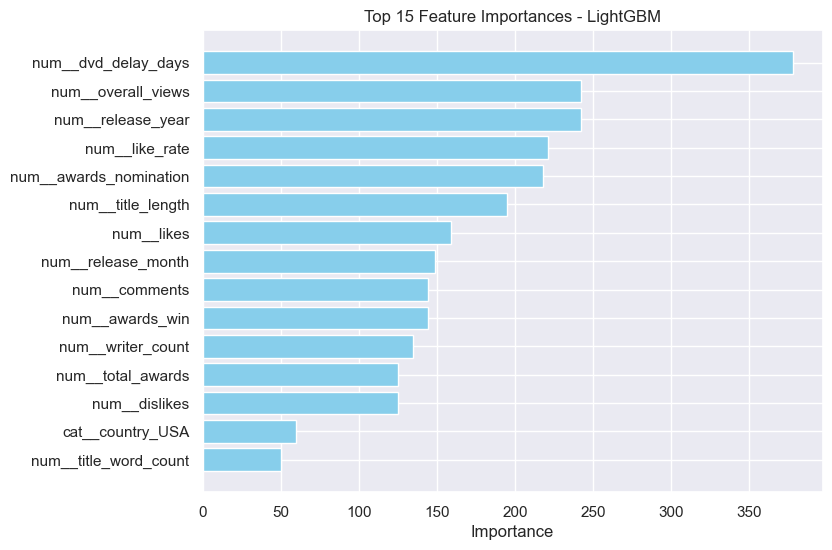

In [323]:
# Visualize top feature importance
plt.figure(figsize=(8,6))

# Create a # horizontal bar chart of feature importances
plt.barh(feat_imp["Feature"], feat_imp["Importance"], color="skyblue")

# Invert y-axis so the most important feature is at the top
plt.gca().invert_yaxis()

# Add titles and axis labels
plt.title("Top 15 Feature Importances - LightGBM")
plt.xlabel("Importance")
plt.show()

### SECTION NINE: FINAL MODEL TRAINING, TESTING AND PREDICTION

In [326]:
# Retrain the model on the full training data to produce a final model
final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(random_state=42))
])

# Fit the final model on all available training data
final_model.fit(x, y)

[LightGBM] [Info] Number of positive: 1221, number of negative: 1179
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000434 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2222
[LightGBM] [Info] Number of data points in the train set: 2400, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.508750 -> initscore=0.035004
[LightGBM] [Info] Start training from score 0.035004


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  ['writer_count', 'comments',
                                                   'likes', 'overall_views',
                                                   'dislikes', 'special_award',
                                                   'awards_win',
                                                   'awards_nomination',
                                                   'release_year',
                                                   'release_month',
                                                   'dvd_delay_days',
                                                   'is_missing_release_date',
                                                   'is_missing_dvd_delay',
                                                   'like_rate', 'engagement',
                                                   'total_awards',
                                                   'title_length',
                                                   'title_word_count']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoded',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['country', 'language',
                                                   'censor_rating'])])),
                ('model', LGBMClassifier(random_state=42))])

#### PREDICTIONS ON TEST DATA

In [329]:
# Import test data from its file path
test_data = pd.read_csv("C:/Users/blaqj/OneDrive/Documents/Projects/Interswitch assessment/watchit_revenue_assessment/test.csv")
test_data.head() # show table summary

,title,country,genres,language,writer_count,title_adaption,censor_rating,release_date,runtime,dvd_release_date,...,comments,likes,overall_views,dislikes,ratings_imdb,ratings_tomatoes,ratings_metacritic,special_award,awards_win,awards_nomination
0,Delhi-6,India,"Comedy, Drama","Hindi, English",3.0,True,Not Rated,20-Feb-09,141 min,16-Jun-09,...,7.0,43.0,165008.0,13.0,6.0/10,40%,45/100,0,2,7
1,Before I Disappear,"USA, UK",Drama,English,1.0,False,Unrated,28-Nov-14,93 min,19-May-15,...,NaN,NaN,NaN,NaN,7.2/10,38%,47/100,0,16,8
2,"Good Year, A","USA, UK","Comedy, Drama, Romance","English, French, Russian",2.0,True,PG-13,10-Nov-06,117 min,27-Feb-07,...,14.0,276.0,187788.0,17.0,7.0/10,25%,47/100,0,1,2
3,Brüno,"USA, UK",Comedy,"English, German",9.0,True,R,10-Jul-09,81 min,17-Nov-09,...,81.0,301.0,200324.0,43.0,5.8/10,67%,54/100,0,2,5
4,How to Lose a Guy in 10 Days,"USA, Germany","Comedy, Romance",English,5.0,True,PG-13,07-Feb-03,116 min,01-Jul-03,...,74.0,480.0,740345.0,23.0,6.4/10,42%,45/100,0,1,8


In [331]:
# Use summarize function to perform EDA on test data
summarize_df(test_data)

==== Dataset ====
(600, 21)
object     12
float64     5
int64       3
bool        1
Name: count, dtype: int64
comments            124
dislikes            123
likes               123
overall_views        93
writer_count         29
dvd_release_date     18
censor_rating        16
release_date          2
title                 0
awards_win            0
dtype: int64


In [333]:
# Use cleaning and feature-engineering function to modify test data and load into a DataFrame
test_data_df = clean_and_engineer(test_data)
print("Test data is all geared up and ready to train") # Print message to ensure function ran successfully

Test data is all geared up and ready to train


In [335]:
# calling EDA function with test data to check how well the raw data was cleaned and engineered
summarize_df(test_data_df)

==== Dataset ====
(600, 31)
object            10
float64           10
int64              6
datetime64[ns]     2
int32              2
bool               1
Name: count, dtype: int64
dvd_release_date           18
release_date                2
title                       0
ratings_metacritic          0
title_length                0
total_awards                0
engagement                  0
like_rate                   0
is_missing_dvd_delay        0
is_missing_release_date     0
dtype: int64


In [337]:
# Preprocess and predict
test_pred = final_model.predict(test_data_df.drop(columns=["title"]))

In [339]:
# Build submission file

# Create a DataFrame with predictions on the test set
submission = pd.DataFrame({
    "Title": test_data_df["title"], # list original movie titles
    "revenue_category": np.where(test_pred==1, "High", "Low") # Map numeric predictions back to labels
})

# Save to CSV
submission.to_csv("submission.csv", index=False)

# Preview first few rows
submission.head()

,Title,revenue_category
0,Delhi-6,Low
1,Before I Disappear,Low
2,"Good Year, A",High
3,Brüno,High
4,How to Lose a Guy in 10 Days,High
